# Deep learning with Pytorch

## `torch.autograd` introduction

In [79]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

Forward pass

In [80]:
prediction = model(data)

Backward pass

In [81]:
loss = (prediction - labels).sum()

loss.backward()

Optimizer

In [82]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

Gradient Descent

In [83]:
optim.step()

### Differentiation in Autograd

In [84]:
a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)

In [85]:
print(f"A's grad = {a.grad}")
print(f"B's grad = {b.grad}")

A's grad = None
B's grad = None


$Q = 3a^3 - b^2$

In [86]:
Q = 3*a**3 - b**2

In [87]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)

$$\frac{\partial{Q}}{\partial{a}} = 9a^2$$
$$\frac{\partial{Q}}{\partial{b}} = -2b$$

In [88]:
print(f"A's grad = {a.grad}")
print(f"B's grad = {b.grad}")

A's grad = tensor([36., 81.])
B's grad = tensor([-12.,  -8.])


## Neural Networks

**Typical CNN pattern**

Conv extracts feature -> ReLU add non-linearity -> max pool shrinks spatial size & keeps strongest signals

In [89]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 5)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, input):
    c1 = F.relu(self.conv1(input))
    s2 = F.max_pool2d(c1, (2, 2))
    c3 = F.relu(self.conv2(s2))
    s4 = F.max_pool2d(c3, 2)
    s4 = torch.flatten(s4, 1)
    f5 = F.relu(self.fc1(s4))
    f6 = F.relu(self.fc2(f5))
    output = self.fc3(f6)
    return output

net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [90]:
params = list(net.parameters())
print(len(params))
print(params[0].size())

10
torch.Size([6, 1, 5, 5])


In [91]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[-0.0204,  0.1191, -0.0262, -0.0754,  0.0130,  0.0222, -0.0298, -0.0802,
          0.0559,  0.0875]], grad_fn=<AddmmBackward0>)


In [92]:
net.zero_grad()
out.backward(torch.randn(1, 10))

### Loss Function

In [93]:
output = net(input)
target = torch.randn(10)  # a dummy target, for example
target = target.view(1, -1)  # make it the same shape as output
criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

tensor(0.5174, grad_fn=<MseLossBackward0>)


In [94]:
print(loss.grad_fn)  # MSELoss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU

### Backprop

In [95]:
net.zero_grad()     # zeroes the gradient buffers of all parameters

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0023,  0.0223, -0.0181, -0.0015, -0.0019,  0.0045])


### Update the weights

In [96]:
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update

## Training a Classifier

In [97]:
import torchvision
from torchvision.transforms import v2

In [98]:
transform = v2.Compose([
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 4
num_workers = 2

train_set = torchvision.datasets.CIFAR10(
  root="./data",
  train=True,
  download=True,
  transform=transform
)
train_loader = torch.utils.data.DataLoader(
  train_set, 
  batch_size=batch_size,
  shuffle=True,
  num_workers=num_workers
)

test_set = torchvision.datasets.CIFAR10(
  root="./data",
  train=False,
  download=True,
  transform=transform
)
test_loader = torch.utils.data.DataLoader(
  test_set,
  batch_size=batch_size,
  shuffle=False,
  num_workers=num_workers
)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


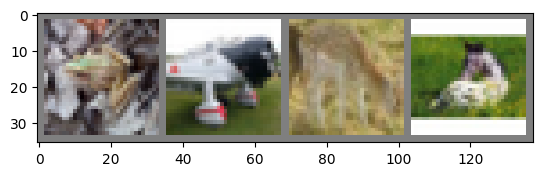

frog  plane deer  horse


In [100]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### Convolutional Neural Network

In [101]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 6, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, 1) # flatten all dimensions except batch
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


net = Net()

### Loss function

In [102]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### Training

In [103]:
for epoch in range(2):
  running_loss = 0.0
  for i, data in enumerate(train_loader, 0):
    inputs, labels = data
    optimizer.zero_grad()

    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    if i % 2000 == 1999:
      print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
      running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.241
[1,  4000] loss: 1.906
[1,  6000] loss: 1.668
[1,  8000] loss: 1.579
[1, 10000] loss: 1.508
[1, 12000] loss: 1.477
[2,  2000] loss: 1.398
[2,  4000] loss: 1.370
[2,  6000] loss: 1.337
[2,  8000] loss: 1.325
[2, 10000] loss: 1.295
[2, 12000] loss: 1.300
Finished Training


In [104]:
model_path = './nn_models/cifar_net.pth'
torch.save(net.state_dict(), model_path)

### Testing neural network

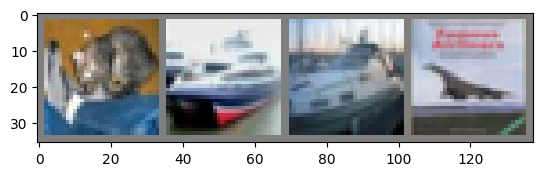

GroundTruth:  cat   ship  ship  plane


In [105]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [106]:
net = Net()
net.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [107]:
outputs = net(images)

In [108]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  plane ship  ship  plane


In [110]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    # calculate outputs by running images through the network
    outputs = net(images)
    # the class with the highest energy is what we choose as prediction
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 55 %


Let's see what are the classes that performed well.

In [112]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    outputs = net(images)
    _, predictions = torch.max(outputs, 1)
    # collect the correct predictions for each class
    for label, prediction in zip(labels, predictions):
      if label == prediction:
        correct_pred[classes[label]] += 1
      total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
  accuracy = 100 * float(correct_count) / total_pred[classname]
  print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 71.3 %
Accuracy for class: car   is 77.0 %
Accuracy for class: bird  is 41.1 %
Accuracy for class: cat   is 35.2 %
Accuracy for class: deer  is 44.8 %
Accuracy for class: dog   is 47.0 %
Accuracy for class: frog  is 58.2 %
Accuracy for class: horse is 62.2 %
Accuracy for class: ship  is 70.1 %
Accuracy for class: truck is 46.4 %
